# Training ANN dari Output Dataset Preprocessing Studio

Notebook ini membaca file hasil fitur **Dataset & Label** dan **Randomize Dataset** dari aplikasi:

- `random_inputs_*.npy`
- `random_labels_*.npy`
- `class_map.csv`

Training dilakukan dengan ANN sederhana berbasis NumPy.

## 1. Konfigurasi Folder Dataset

Ganti `DATASET_DIR` ke folder output aplikasi yang berisi file `random_inputs_*.npy` dan `random_labels_*.npy`.

In [1]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

In [2]:


DATASET_DIR = Path(r"Dataset_Jadi")

DATASET_LABEL_DIR = DATASET_DIR / "dataset_label"
RANDOMIZE_DIR = DATASET_DIR / "randomize_dataset"

def latest_file(folder, pattern):
    files = sorted(folder.glob(pattern), key=lambda path: path.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f"File {pattern} tidak ditemukan di {folder.resolve()}")
    return files[-1]

input_path = latest_file(RANDOMIZE_DIR, "random_inputs_*.npy")
label_path = latest_file(RANDOMIZE_DIR, "random_labels_*.npy")
class_map_path = DATASET_LABEL_DIR / "class_map.csv"
random_index_path = RANDOMIZE_DIR / "random_index.csv"

print("Input file :", input_path)
print("Label file :", label_path)
print("Class map  :", class_map_path)
print("Random map :", random_index_path)

Input file : Dataset_Jadi\randomize_dataset\random_inputs_200_601.npy
Label file : Dataset_Jadi\randomize_dataset\random_labels_200_11.npy
Class map  : Dataset_Jadi\dataset_label\class_map.csv
Random map : Dataset_Jadi\randomize_dataset\random_index.csv


## 2. Load Inputs dan Labels

Kolom ke-0 pada file input dan label adalah nomor sampel, jadi tidak dipakai sebagai fitur training.

In [3]:
raw_inputs = np.load(input_path)
raw_labels = np.load(label_path)

sample_ids = raw_inputs[:, 0].astype(int)
X = raw_inputs[:, 1:].astype(np.float32) / 255.0
Y = raw_labels[:, 1:].astype(np.float32)

print("raw_inputs shape:", raw_inputs.shape)
print("raw_labels shape:", raw_labels.shape)
print("X shape         :", X.shape)
print("Y shape         :", Y.shape)
print("Jumlah kelas    :", Y.shape[1])
print("Min/Max X       :", X.min(), X.max())

raw_inputs shape: (200, 601)
raw_labels shape: (200, 11)
X shape         : (200, 600)
Y shape         : (200, 10)
Jumlah kelas    : 10
Min/Max X       : 0.0 1.0


## 3. Load Class Map dan Random Index

In [4]:
classes = []
if class_map_path.exists():
    with open(class_map_path, newline="", encoding="utf-8") as file:
        reader = csv.DictReader(file)
        for row in reader:
            classes.append(row["label"])
else:
    classes = [f"class_{index}" for index in range(Y.shape[1])]

random_rows = []
if random_index_path.exists():
    with open(random_index_path, newline="", encoding="utf-8") as file:
        random_rows = list(csv.DictReader(file))

print(classes)
print("Jumlah mapping random:", len(random_rows))

['katakana(a)', 'katakana(ha)', 'katakana(ka)', 'katakana(ma)', 'katakana(na)', 'katakana(ra)', 'katakana(sa)', 'katakana(ta)', 'katakana(wa)', 'katakana(ya)']
Jumlah mapping random: 200


## 4. Definisi ANN Low-Level NumPy

In [5]:
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

def sigmoid_derivative(output):
    return output * (1 - output)

def initialize_model(input_neurons, hidden_neurons, output_neurons, seed=42):
    rng = np.random.default_rng(seed)
    input_limit = np.sqrt(6 / (input_neurons + hidden_neurons))
    output_limit = np.sqrt(6 / (hidden_neurons + output_neurons))
    model = {
        "w_i_h": rng.uniform(-input_limit, input_limit, (hidden_neurons, input_neurons)),
        "b_i_h": np.zeros((hidden_neurons, 1)),
        "w_h_o": rng.uniform(-output_limit, output_limit, (output_neurons, hidden_neurons)),
        "b_h_o": np.zeros((output_neurons, 1)),
    }
    return model

def forward(model, inp):
    h_pre = model["b_i_h"] + model["w_i_h"] @ inp
    h = sigmoid(h_pre)
    o_pre = model["b_h_o"] + model["w_h_o"] @ h
    o = sigmoid(o_pre)
    return h, o

def train_ann(X, Y, hidden_neurons=40, epochs=300, learning_rate=0.1):
    input_neurons = X.shape[1]
    output_neurons = Y.shape[1]
    model = initialize_model(input_neurons, hidden_neurons, output_neurons)
    history = []

    for epoch in range(1, epochs + 1):
        correct = 0
        total_loss = 0.0

        for features, target in zip(X, Y):
            inp = features.reshape(-1, 1)
            label = target.reshape(-1, 1)

            h, o = forward(model, inp)
            error = o - label
            total_loss += np.mean(error ** 2)
            correct += int(np.argmax(o) == np.argmax(label))

            delta_o = error * sigmoid_derivative(o)
            delta_h = (model["w_h_o"].T @ delta_o) * sigmoid_derivative(h)

            model["w_h_o"] -= learning_rate * delta_o @ h.T
            model["b_h_o"] -= learning_rate * delta_o
            model["w_i_h"] -= learning_rate * delta_h @ inp.T
            model["b_i_h"] -= learning_rate * delta_h

        accuracy = correct / len(X)
        loss = total_loss / len(X)
        history.append((epoch, loss, accuracy))

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"Epoch {epoch:03d} | loss={loss:.6f} | accuracy={accuracy:.2%}")

    return model, np.array(history)

## 5. Training

In [6]:
model, history = train_ann(
    X,
    Y,
    hidden_neurons=40,
    epochs=300,
    learning_rate=0.1
)

Epoch 001 | loss=0.093854 | accuracy=7.50%
Epoch 010 | loss=0.090272 | accuracy=10.50%
Epoch 020 | loss=0.085415 | accuracy=21.00%
Epoch 030 | loss=0.076109 | accuracy=32.50%
Epoch 040 | loss=0.068384 | accuracy=44.00%
Epoch 050 | loss=0.062052 | accuracy=53.00%
Epoch 060 | loss=0.055501 | accuracy=60.50%
Epoch 070 | loss=0.049299 | accuracy=66.00%
Epoch 080 | loss=0.043760 | accuracy=71.00%
Epoch 090 | loss=0.039682 | accuracy=74.00%
Epoch 100 | loss=0.036141 | accuracy=78.00%
Epoch 110 | loss=0.033137 | accuracy=81.00%
Epoch 120 | loss=0.029670 | accuracy=82.50%
Epoch 130 | loss=0.025556 | accuracy=85.50%
Epoch 140 | loss=0.022396 | accuracy=86.00%
Epoch 150 | loss=0.020009 | accuracy=87.00%
Epoch 160 | loss=0.018570 | accuracy=86.50%
Epoch 170 | loss=0.017180 | accuracy=88.50%
Epoch 180 | loss=0.016266 | accuracy=89.50%
Epoch 190 | loss=0.015318 | accuracy=89.50%
Epoch 200 | loss=0.014635 | accuracy=91.00%
Epoch 210 | loss=0.014241 | accuracy=92.50%
Epoch 220 | loss=0.014713 | accur

## 6. Grafik Loss dan Accuracy

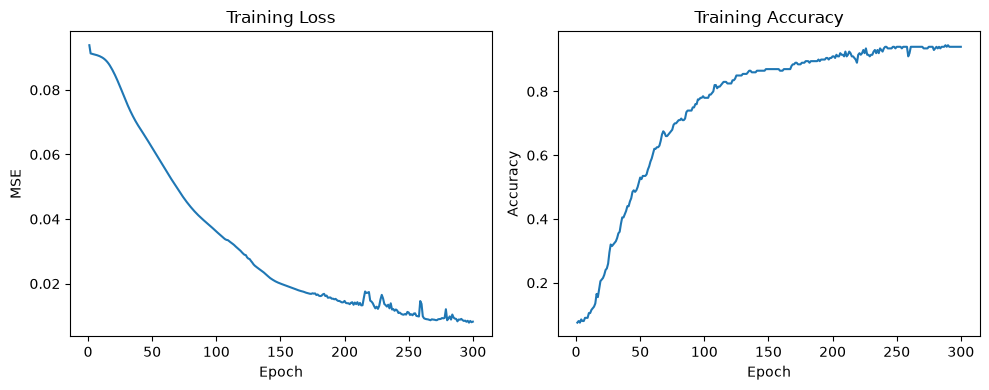

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history[:, 0], history[:, 1])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.subplot(1, 2, 2)
plt.plot(history[:, 0], history[:, 2])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 7. Evaluasi Insample

In [8]:
predictions = []
targets = []

for features, target in zip(X, Y):
    _, output = forward(model, features.reshape(-1, 1))
    predictions.append(int(np.argmax(output)))
    targets.append(int(np.argmax(target)))

predictions = np.array(predictions)
targets = np.array(targets)
accuracy = np.mean(predictions == targets)
print(f"Akurasi insample: {accuracy:.2%}")

for index in range(min(10, len(X))):
    pred_label = classes[predictions[index]] if predictions[index] < len(classes) else predictions[index]
    true_label = classes[targets[index]] if targets[index] < len(classes) else targets[index]
    print(f"Sample {sample_ids[index]} | target={true_label} | prediksi={pred_label}")

Akurasi insample: 93.00%
Sample 19 | target=katakana(a) | prediksi=katakana(a)
Sample 107 | target=katakana(ra) | prediksi=katakana(ra)
Sample 167 | target=katakana(wa) | prediksi=katakana(wa)
Sample 153 | target=katakana(ta) | prediksi=katakana(ta)
Sample 165 | target=katakana(wa) | prediksi=katakana(wa)
Sample 37 | target=katakana(ha) | prediksi=katakana(ha)
Sample 92 | target=katakana(na) | prediksi=katakana(na)
Sample 58 | target=katakana(ka) | prediksi=katakana(ka)
Sample 99 | target=katakana(na) | prediksi=katakana(na)
Sample 119 | target=katakana(ra) | prediksi=katakana(ra)


## 8. Simpan Bobot Model

In [9]:
np.save(DATASET_DIR / "ann_w_i_h.npy", model["w_i_h"])
np.save(DATASET_DIR / "ann_b_i_h.npy", model["b_i_h"])
np.save(DATASET_DIR / "ann_w_h_o.npy", model["w_h_o"])
np.save(DATASET_DIR / "ann_b_h_o.npy", model["b_h_o"])
print("Bobot model disimpan di:", DATASET_DIR.resolve())

Bobot model disimpan di: C:\Perkuliahan\Semester 6\Image Processing\Proyek Kelompok Image Processing\Dataset_Jadi


## 9. Inference dari Model yang Sudah Disimpan

Bagian ini memuat ulang bobot ANN dari file `.npy`, lalu melakukan prediksi tanpa training ulang.

In [10]:
def load_saved_model(dataset_dir):
    return {
        "w_i_h": np.load(dataset_dir / "ann_w_i_h.npy"),
        "b_i_h": np.load(dataset_dir / "ann_b_i_h.npy"),
        "w_h_o": np.load(dataset_dir / "ann_w_h_o.npy"),
        "b_h_o": np.load(dataset_dir / "ann_b_h_o.npy"),
    }

def predict_features(saved_model, features):
    inp = features.astype(np.float32).reshape(-1, 1)
    _, output = forward(saved_model, inp)
    class_index = int(np.argmax(output))
    confidence = float(output[class_index, 0])
    label = classes[class_index] if class_index < len(classes) else f"class_{class_index}"
    return label, class_index, confidence, output.reshape(-1)

saved_model = load_saved_model(DATASET_DIR)
print("Model tersimpan berhasil dimuat.")

Model tersimpan berhasil dimuat.


### 9.1 Inference dari Sample Dataset

Gunakan ini untuk membuktikan model dapat membaca ulang data dari `random_inputs_*.npy`.

In [11]:
SAMPLE_INDEX = 10

features = X[SAMPLE_INDEX]
target_index = int(np.argmax(Y[SAMPLE_INDEX]))
target_label = classes[target_index] if target_index < len(classes) else f"class_{target_index}"
pred_label, pred_index, confidence, raw_output = predict_features(saved_model, features)

print("Random Index :", SAMPLE_INDEX)
print("Sample ID    :", sample_ids[SAMPLE_INDEX])
if random_rows and SAMPLE_INDEX < len(random_rows):
    row = random_rows[SAMPLE_INDEX]
    print("Filename     :", row.get("filename"))
    print("Image copy   :", RANDOMIZE_DIR / row.get("image_copy", ""))
print("Target       :", target_label)
print("Prediksi     :", pred_label)
print("Confidence   :", confidence)
print("Output neuron:", raw_output)

Random Index : 10
Sample ID    : 28
Filename     : katakana(ha)_ (17)_gray_average_20x30_bin128.jpg
Image copy   : Dataset_Jadi\randomize_dataset\images\010_from_028_katakana(ha)_ (17)_gray_average_20x30_bin128.jpg
Target       : katakana(ha)
Prediksi     : katakana(ha)
Confidence   : 0.912072744236938
Output neuron: [1.19962180e-05 9.12072744e-01 4.92039884e-04 8.03916611e-04
 3.22421680e-03 5.88029852e-03 9.62679510e-05 2.36694549e-02
 8.15556787e-03 6.46039460e-03]


### 9.2 Inference dari File Gambar Ready

Gunakan gambar hasil preprocessing akhir, misalnya file `*_ready.jpg` dari folder `binarization`. Ukuran gambar harus sama dengan fitur input model.

In [24]:
IMAGE_PATH = RANDOMIZE_DIR / "images" / "contoh_ready.jpg"

def image_to_features(image_path):
    image = plt.imread(image_path)
    if image.dtype != np.uint8:
        image = np.clip(image * 255 if image.max() <= 1.0 else image, 0, 255).astype(np.uint8)
    if image.ndim == 3:
        image = image[:, :, 0]
    features = image.reshape(-1).astype(np.float32) / 255.0
    expected_features = saved_model["w_i_h"].shape[1]
    if features.shape[0] != expected_features:
        raise ValueError(f"Jumlah fitur gambar {features.shape[0]} tidak sama dengan input model {expected_features}.")
    return features, image

if IMAGE_PATH.exists():
    features, image = image_to_features(IMAGE_PATH)
    pred_label, pred_index, confidence, raw_output = predict_features(saved_model, features)
    print("File       :", IMAGE_PATH)
    print("Prediksi   :", pred_label)
    print("Confidence :", confidence)
    plt.imshow(image, cmap="gray")
    plt.title(f"Prediksi: {pred_label}")
    plt.axis("off")
    plt.show()
else:
    print("File gambar belum ditemukan. Ubah IMAGE_PATH ke file *_ready.jpg yang ingin diuji.")

File gambar belum ditemukan. Ubah IMAGE_PATH ke file *_ready.jpg yang ingin diuji.
